### Use Conda as VDB package isn't available on pip

### Clean folder names 
Replace empty spaces and hyphens with underscores for easier access.

In [ ]:
from pathlib import Path
import re

def replace(name):
    name = re.sub(r' +', '_', name)
    name = name.replace("-", "_")
    name = re.sub(r'_+', '_', name) 
    return name

def rename(base_path):
    root = Path(base_path)
    
    for folder in root.glob("*/*"):
        if folder.is_dir():
            new_folder = folder.parent / replace(folder.name)
            if folder != new_folder:
                folder.rename(new_folder)

    for sub_parent in root.iterdir():
        if sub_parent.is_dir():
            new_sub = sub_parent.parent / replace(sub_parent.name)
            sub_parent.rename(new_sub)

    new_root = root.parent / replace(root.name)
    root.rename(new_root)

target = r"PKG - UCSF-PDGM Version 5"
rename(target)

### Visualization 
Opening a random MRI using Nibabel and visualising a 3D volume using Matplotlib with a slider for depth

In [1]:
%pip install nibabel matplotlib

  Using cached nibabel-5.4.2-py3-none-any.whl.metadata (8.9 kB)
  Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl.metadata (52 kB)
   ---------------------------------------- 0.0/3.3 MB ? eta -:--:--
   ---------------------------------------- 3.3/3.3 MB 29.7 MB/s  0:00:00
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ------------------------- -------------- 5.2/8.1 MB 26.2 MB/s eta 0:00:01
   ------------------------------------- -- 7.6/8.1 MB 18.7 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 15.4 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ------------- -------------------------- 0.8/2.3 MB 4.9 MB/s eta 0:00:01
   ----------------------------------- ---- 2.1/2.3 MB 5.2 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 5.2 MB/s  0:00:00
   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   --- ------------------------------------ 1.0/12.3 MB 

Visualizing: UCSF-PDGM-0204_DWI_bias.nii.gz


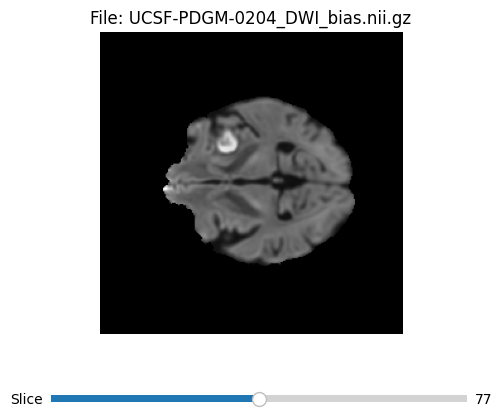

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
import nibabel as nib
from pathlib import Path
import random

def visualize(base_path):
    path = Path(base_path)
    nifti_files = list(path.rglob("*.nii.gz"))
    
    if not nifti_files:
        print("No NIfTI files found.")
        return

    random_file = random.choice(nifti_files)
    print(f"Visualizing: {random_file.name}")
    
    img = nib.load(random_file)
    data = img.get_fdata()
    
    fig, ax = plt.subplots()
    plt.subplots_adjust(bottom=0.25)
    
    initial_slice = data.shape[2] // 2
    l = ax.imshow(data[:, :, initial_slice], cmap="gray", origin="lower")
    ax.set_title(f"File: {random_file.name}")
    ax.axis("off")

    ax_slider = plt.axes([0.2, 0.1, 0.65, 0.03])
    slider = Slider(ax_slider, 'Slice', 0, data.shape[2] - 1, valinit=initial_slice, valfmt='%d')

    def update(val):
        idx = int(slider.val)
        l.set_data(data[:, :, idx])
        fig.canvas.draw_idle()

    slider.on_changed(update)
    plt.show()

target_path = r"PKG_UCSF_PDGM_Version_5\PKG_UCSF_PDGM_Version_5"
visualize(target_path)

### Segmentation
MONAI Model Zoo to get pretrained models for brain matter and tumor segmentation

In [1]:
%pip install torch torchvision --index-url https://download.pytorch.org/whl/cu130
%pip install monai[all] requests huggingface_hub pytorch-ignite

Looking in indexes: https://download.pytorch.org/whl/cu130
Note: you may need to restart the kernel to use updated packages.
  Using cached huggingface_hub-1.8.0-py3-none-any.whl.metadata (13 kB)
  Using cached monai-1.5.2-py3-none-any.whl.metadata (13 kB)
  Using cached clearml-2.1.6rc0-py2.py3-none-any.whl.metadata (18 kB)
  Using cached gdown-5.2.1-py3-none-any.whl.metadata (5.8 kB)
  Using cached itk-5.4.5-cp311-abi3-win_amd64.whl.metadata (22 kB)
  Using cached jsonschema-4.26.0-py3-none-any.whl.metadata (7.6 kB)
  Using cached lpips-0.1.4-py3-none-any.whl.metadata (10 kB)
  Using cached mlflow-3.10.1-py3-none-any.whl.metadata (31 kB)
  Using cached optuna-4.8.0-py3-none-any.whl.metadata (17 kB)
  Using cached torchio-1.0.1-py3-none-any.whl.metadata (53 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached typer-0.24.1-py3-none-any.whl.metadata (16 kB)
  Using cached itk_filtering-5.4.5-cp311-abi3-win_amd64.whl.metadata (22 kB)
  Using cached itk_regist

In [ ]:
import json
import matplotlib.pyplot as plt
from monai.bundle import download, run
import nibabel as nib
from pathlib import Path
import random

def generate_and_visualize(base_path):
    root = Path(base_path)
    subjects = [d for d in root.iterdir() if d.is_dir()]
    subject = random.choice(subjects)
    print(f"--- Processing Subject: {subject.name} ---")

    flair = next(subject.glob("*_FLAIR_bias.nii.gz"))
    t1c = next(subject.glob("*_T1c_bias.nii.gz"))
    t1 = next(subject.glob("*_T1_bias.nii.gz"))
    t2 = next(subject.glob("*_T2_bias.nii.gz"))

    brats_inputs = [str(flair.name), str(t1c.name), str(t1.name), str(t2.name)]
    unest_input = str(t1.name)

    brats_datalist = subject / "brats_datalist.json"
    with open(brats_datalist, "w") as f:
        json.dump({"testing": [{"image": brats_inputs}]}, f)

    unest_datalist = subject / "unest_datalist.json"
    with open(unest_datalist, "w") as f:
        json.dump({"testing": [{"image": unest_input}]}, f)

    bundle_name = "brats_mri_segmentation"
    model_path = Path("./models") / bundle_name
    brats_root = model_path / bundle_name
    download(name=bundle_name, bundle_dir=model_path)

    output_path = Path("results") / subject.name
    output_path.mkdir(parents=True, exist_ok=True)
    
    run(
        bundle_root=str(brats_root),
        config_file=str(brats_root / "configs" / "inference.json"),
        data_list_file_path=str(brats_datalist), 
        dataset_dir=str(subject),
        output_dir=str(subject)
    )

    unest_bundle = "wholeBrainSeg_Large_UNEST_segmentation"
    unest_model_path = Path("./models") / unest_bundle
    unest_root = unest_model_path / unest_bundle
    download(name=unest_bundle, bundle_dir=unest_model_path)

    run(
        bundle_root=str(unest_root),
        config_file=str(unest_root / "configs" / "inference.json"),
        data_list_file_path=str(unest_datalist),
        dataset_dir=str(subject),
        output_dir=str(subject),
        run_id="evaluating"
    )

    visualize_results(subject)

def visualize_results(subject_path):
    tumor_path = list(subject_path.glob("*_FLAIR_bias_seg.nii.gz"))[0]
    anatomy_path = list(subject_path.glob("*_T1_bias_seg.nii.gz"))[0]
    original_path = list(subject_path.glob("*_T1_bias.nii.gz"))[0]

    img = nib.load(original_path).get_fdata()
    tumor = nib.load(tumor_path).get_fdata()
    anatomy = nib.load(anatomy_path).get_fdata()

    slice_idx = img.shape[2] // 2

    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.title("Original T1 MRI")
    plt.imshow(img[:, :, slice_idx], cmap='gray')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.title("Tumor Mask (BraTS)")
    plt.imshow(img[:, :, slice_idx], cmap='gray')
    plt.imshow(tumor[:, :, slice_idx], alpha=0.5, cmap='Reds')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.title("Anatomy Mask (UNEST)")
    plt.imshow(img[:, :, slice_idx], cmap='gray')
    plt.imshow(anatomy[:, :, slice_idx], alpha=0.5, cmap='jet')
    plt.axis('off')

    plt.show()

target = r"PKG_UCSF_PDGM_Version_5\PKG_UCSF_PDGM_Version_5"
generate_and_visualize(target)

--- Processing Subject: UCSF_PDGM_0388_nifti ---
2026-03-25 11:11:50,267 - INFO - --- input summary of monai.bundle.scripts.download ---
2026-03-25 11:11:50,267 - INFO - > name: 'brats_mri_segmentation'
2026-03-25 11:11:50,268 - INFO - > bundle_dir: WindowsPath('models/brats_mri_segmentation')
2026-03-25 11:11:50,268 - INFO - > source: 'monaihosting'
2026-03-25 11:11:50,268 - INFO - > remove_prefix: 'monai_'
2026-03-25 11:11:50,268 - INFO - > progress: True
2026-03-25 11:11:50,269 - INFO - ---


2026-03-25 11:11:51,225 - httpx - INFO - HTTP Request: GET https://huggingface.co/api/models/MONAI/brats_mri_segmentation/revision/0.5.4 "HTTP/1.1 200 OK"


Fetching 14 files: 100%|██████████| 14/14 [00:00<00:00, 2539.47it/s]

2026-03-25 11:11:51,254 - INFO - Setting logging properties based on config: models\brats_mri_segmentation\brats_mri_segmentation\configs\logging.conf.
2026-03-25 11:11:51,357 - root - INFO - Restored all variables from models\brats_mri_segmentation\brats_mri_segmentation/models/model.pt
2026-03-25 11:11:51,358 - INFO - --- input summary of monai.bundle.scripts.run ---
2026-03-25 11:11:51,358 - INFO - > bundle_root: 'models\\brats_mri_segmentation\\brats_mri_segmentation'
2026-03-25 11:11:51,358 - INFO - > data_list_file_path: 'PKG_UCSF_PDGM_Version_5\\PKG_UCSF_PDGM_Version_5\\UCSF_PDGM_0388_nifti\\brats_datalist.json'
2026-03-25 11:11:51,359 - INFO - > dataset_dir: 'PKG_UCSF_PDGM_Version_5\\PKG_UCSF_PDGM_Version_5\\UCSF_PDGM_0388_nifti'
2026-03-25 11:11:51,359 - INFO - > output_dir: 'PKG_UCSF_PDGM_Version_5\\PKG_UCSF_PDGM_Version_5\\UCSF_PDGM_0388_nifti'
2026-03-25 11:11:51,359 - INFO - ---


2026-03-25 11:11:51,360 - ignite.engine.engine.SupervisedEvaluator - INFO - Engine run resumi

2026-03-25 11:12:04,257 INFO image_writer.py:197 - writing: PKG_UCSF_PDGM_Version_5\PKG_UCSF_PDGM_Version_5\UCSF_PDGM_0388_nifti\UCSF-PDGM-0388_FLAIR_bias\UCSF-PDGM-0388_FLAIR_bias_seg.nii.gz
2026-03-25 11:12:04,303 - ignite.engine.engine.SupervisedEvaluator - INFO - Epoch[1] Complete. Time taken: 00:00:12.651
2026-03-25 11:12:04,304 - ignite.engine.engine.SupervisedEvaluator - INFO - Engine run finished. Time taken: 00:00:12.944
2026-03-25 11:12:05,360 - INFO - --- input summary of monai.bundle.scripts.download ---
2026-03-25 11:12:05,361 - INFO - > name: 'wholeBrainSeg_Large_UNEST_segmentation'
2026-03-25 11:12:05,362 - INFO - > bundle_dir: WindowsPath('models/wholeBrainSeg_Large_UNEST_segmentation')
2026-03-25 11:12:05,362 - INFO - > source: 'monaihosting'
2026-03-25 11:12:05,362 - INFO - > remove_prefix: 'monai_'
2026-03-25 11:12:05,363 - INFO - > progress: True
2026-03-25 11:12:05,363 - INFO - ---


2026-03-25 11:12:05,881 - httpx - INFO - HTTP Request: GET https://huggingface.co/

Fetching 22 files: 100%|██████████| 22/22 [00:00<00:00, 909.63it/s]

2026-03-25 11:12:05,921 - INFO - Setting logging properties based on config: models\wholeBrainSeg_Large_UNEST_segmentation\wholeBrainSeg_Large_UNEST_segmentation\configs\logging.conf.
2026-03-25 11:12:05,925 - INFO - --- input summary of monai.bundle.scripts.run ---
2026-03-25 11:12:05,926 - INFO - > run_id: 'evaluating'
2026-03-25 11:12:05,926 - INFO - > bundle_root: 'models\\wholeBrainSeg_Large_UNEST_segmentation\\wholeBrainSeg_Large_UNEST_segmentation'
2026-03-25 11:12:05,927 - INFO - > data_list_file_path: 'PKG_UCSF_PDGM_Version_5\\PKG_UCSF_PDGM_Version_5\\UCSF_PDGM_0388_nifti\\unest_datalist.json'
2026-03-25 11:12:05,928 - INFO - > dataset_dir: 'PKG_UCSF_PDGM_Version_5\\PKG_UCSF_PDGM_Version_5\\UCSF_PDGM_0388_nifti'
2026-03-25 11:12:05,928 - INFO - > output_dir: 'PKG_UCSF_PDGM_Version_5\\PKG_UCSF_PDGM_Version_5\\UCSF_PDGM_0388_nifti'
2026-03-25 11:12:05,929 - INFO - ---




2026-03-25 11:12:06,526 - ignite.engine.engine.SupervisedEvaluator - INFO - Engine run resuming from iteration 0, epoch 0 until 1 epochs
2026-03-25 11:12:06,821 - ignite.engine.engine.SupervisedEvaluator - INFO - Restored all variables from models\wholeBrainSeg_Large_UNEST_segmentation\wholeBrainSeg_Large_UNEST_segmentation/models/model.pt
2026-03-25 11:16:28,722 INFO image_writer.py:197 - writing: PKG_UCSF_PDGM_Version_5\PKG_UCSF_PDGM_Version_5\UCSF_PDGM_0388_nifti\UCSF-PDGM-0388_ADC\UCSF-PDGM-0388_ADC_trans.nii.gz
2026-03-25 11:20:43,916 INFO image_writer.py:197 - writing: PKG_UCSF_PDGM_Version_5\PKG_UCSF_PDGM_Version_5\UCSF_PDGM_0388_nifti\UCSF-PDGM-0388_ASL\UCSF-PDGM-0388_ASL_trans.nii.gz
2026-03-25 11:24:59,332 INFO image_writer.py:197 - writing: PKG_UCSF_PDGM_Version_5\PKG_UCSF_PDGM_Version_5\UCSF_PDGM_0388_nifti\UCSF-PDGM-0388_DTI_eddy_FA\UCSF-PDGM-0388_DTI_eddy_FA_trans.nii.gz
2026-03-25 11:29:12,565 INFO image_writer.py:197 - writing: PKG_UCSF_PDGM_Version_5\PKG_UCSF_PDGM_Vers

RuntimeError: Failed to evaluate ConfigExpression: 
"$__local_refs['evaluator'].run()"

### Mistake Cleanup
Set the same input and output directory. Cleaning up the output files

In [2]:
from pathlib import Path

def cleanup_dataset(dataset_dir):
    target_dir = Path(dataset_dir)
    
    for file_path in target_dir.rglob("*_seg.nii.gz"):
        file_path.unlink()
        
    for file_path in target_dir.rglob("*_trans.nii.gz"):
        file_path.unlink()

    for file_path in target_dir.rglob("*.json"):
        file_path.unlink()

    for dir_path in sorted(target_dir.rglob("*"), reverse=True):
        if dir_path.is_dir() and not any(dir_path.iterdir()):
            dir_path.rmdir()

cleanup_dataset(r"PKG_UCSF_PDGM_Version_5\PKG_UCSF_PDGM_Version_5")

def cleanup_json_files(base_path):
    root = Path(base_path)
    for json_file in root.rglob("*.json"):
        if json_file.name in ["brats_datalist.json", "unest_datalist.json"]:
            json_file.unlink()
            
cleanup_json_files(r"PKG_UCSF_PDGM_Version_5\PKG_UCSF_PDGM_Version_5")

### Corrected segmentation

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


--- Processing Subject: UCSF_PDGM_0232_nifti ---
2026-04-01 02:41:31,594 - INFO - --- input summary of monai.bundle.scripts.download ---
2026-04-01 02:41:31,595 - INFO - > name: 'brats_mri_segmentation'
2026-04-01 02:41:31,595 - INFO - > bundle_dir: WindowsPath('models/brats_mri_segmentation')
2026-04-01 02:41:31,596 - INFO - > source: 'monaihosting'
2026-04-01 02:41:31,596 - INFO - > remove_prefix: 'monai_'
2026-04-01 02:41:31,596 - INFO - > progress: True
2026-04-01 02:41:31,597 - INFO - ---




Fetching 14 files: 100%|██████████| 14/14 [00:00<00:00, 2396.55it/s]


2026-04-01 02:41:33,744 - INFO - Setting logging properties based on config: models\brats_mri_segmentation\brats_mri_segmentation\configs\logging.conf.
2026-04-01 02:41:33,924 - root - INFO - Restored all variables from models\brats_mri_segmentation\brats_mri_segmentation/models/model.pt
2026-04-01 02:41:33,925 - INFO - --- input summary of monai.bundle.scripts.run ---
2026-04-01 02:41:33,926 - INFO - > bundle_root: 'models\\brats_mri_segmentation\\brats_mri_segmentation'
2026-04-01 02:41:33,926 - INFO - > data_list_file_path: 'results\\UCSF_PDGM_0232_nifti\\brats_datalist.json'
2026-04-01 02:41:33,926 - INFO - > dataset_dir: 'PKG_UCSF_PDGM_Version_5\\PKG_UCSF_PDGM_Version_5\\UCSF_PDGM_0232_nifti'
2026-04-01 02:41:33,927 - INFO - > output_dir: 'results\\UCSF_PDGM_0232_nifti\\Tumor'
2026-04-01 02:41:33,927 - INFO - > sw_batch_size: 1
2026-04-01 02:41:33,927 - INFO - ---


2026-04-01 02:41:33,928 - ignite.engine.engine.SupervisedEvaluator - INFO - Engine run resuming from iteration 0, ep

Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\python_variable_indexing.cpp:353.)


...

Fetching 22 files: 100%|██████████| 22/22 [00:00<00:00, 1723.83it/s]

2026-04-01 02:41:45,796 - INFO - Setting logging properties based on config: models\wholeBrainSeg_Large_UNEST_segmentation\wholeBrainSeg_Large_UNEST_segmentation\configs\logging.conf.
2026-04-01 02:41:45,801 - INFO - --- input summary of monai.bundle.scripts.run ---
2026-04-01 02:41:45,802 - INFO - > run_id: 'evaluating'
2026-04-01 02:41:45,803 - INFO - > bundle_root: 'models\\wholeBrainSeg_Large_UNEST_segmentation\\wholeBrainSeg_Large_UNEST_segmentation'
2026-04-01 02:41:45,804 - INFO - > dataset_dir: 'results\\UCSF_PDGM_0232_nifti\\temp_unest_input'
2026-04-01 02:41:45,804 - INFO - > output_dir: 'results\\UCSF_PDGM_0232_nifti\\Anatomy'
2026-04-01 02:41:45,805 - INFO - > sw_batch_size: 1
2026-04-01 02:41:45,805 - INFO - ---




2026-04-01 02:41:46,417 - ignite.engine.engine.SupervisedEvaluator - INFO - Engine run resuming from iteration 0, epoch 0 until 1 epochs
2026-04-01 02:41:46,667 - ignite.engine.engine.SupervisedEvaluator - INFO - Restored all variables from models\wholeBrainSeg_Large_UNEST_segmentation\wholeBrainSeg_Large_UNEST_segmentation/models/model.pt


Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\python_variable_indexing.cpp:353.)


2026-04-01 02:45:57,918 INFO image_writer.py:197 - writing: results\UCSF_PDGM_0232_nifti\Anatomy\UCSF-PDGM-0232_T1_bias\UCSF-PDGM-0232_T1_bias_trans.nii.gz
2026-04-01 02:45:58,137 - ignite.engine.engine.SupervisedEvaluator - INFO - Epoch[1] Complete. Time taken: 00:04:11.295
2026-04-01 02:45:58,138 - ignite.engine.engine.SupervisedEvaluator - INFO - Engine run complete. Time taken: 00:04:11.720


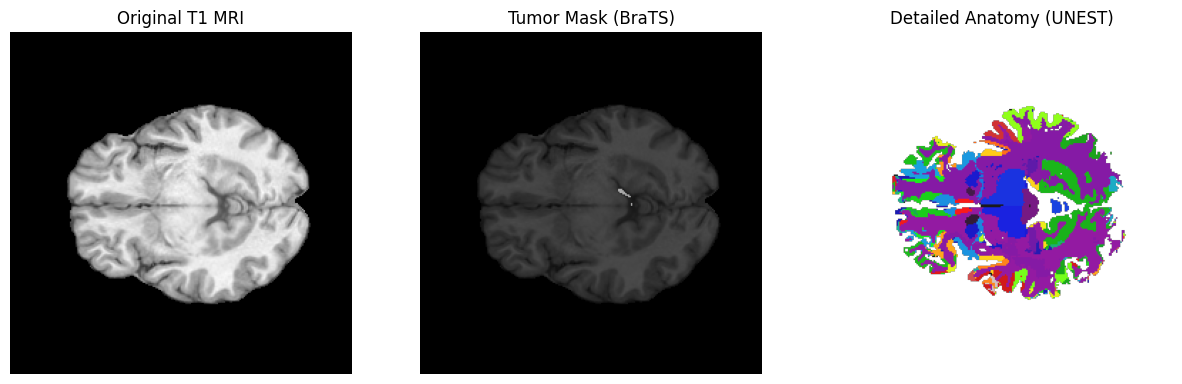

In [2]:
import gc
import json
import matplotlib.pyplot as plt
from monai.bundle import download, run
import nibabel as nib
import numpy as np
from pathlib import Path
import random
import shutil
import torch

def cleanup_gpu():
    """Forces PyTorch to release cached GPU memory."""
    gc.collect()
    torch.cuda.empty_cache()
    
def generate_and_visualize(base_path):
    root = Path(base_path)
    subjects = [d for d in root.iterdir() if d.is_dir()]
    subject = random.choice(subjects)
    print(f"--- Processing Subject: {subject.name} ---")

    flair = next(subject.glob("*_FLAIR_bias.nii.gz"))
    t1c = next(subject.glob("*_T1c_bias.nii.gz"))
    t1 = next(subject.glob("*_T1_bias.nii.gz"))
    t2 = next(subject.glob("*_T2_bias.nii.gz"))

    brats_inputs = [str(flair.name), str(t1c.name), str(t1.name), str(t2.name)]


    bundle_name = "brats_mri_segmentation"
    model_path = Path("./models") / bundle_name
    brats_root = model_path / bundle_name
    download(name=bundle_name, bundle_dir=model_path)

    output_path = Path("results") / subject.name
    output_path.mkdir(parents=True, exist_ok=True)

    brats_datalist = output_path / "brats_datalist.json"
    with open(brats_datalist, "w") as f:
        json.dump({"testing": [{"image": brats_inputs}]}, f)
    
    run(
        bundle_root=str(brats_root),
        config_file=str(brats_root / "configs" / "inference.json"),
        data_list_file_path=str(brats_datalist), 
        dataset_dir=str(subject),
        output_dir=str(output_path / "Tumor"),
        sw_batch_size=1  
    )

    cleanup_gpu()

    unest_bundle = "wholeBrainSeg_Large_UNEST_segmentation"
    unest_model_path = Path("./models") / unest_bundle
    unest_root = unest_model_path / unest_bundle
    download(name=unest_bundle, bundle_dir=unest_model_path)

    unest_temp_dir = output_path / "temp_unest_input"
    unest_temp_dir.mkdir(parents=True, exist_ok=True)
    temp_t1_path = unest_temp_dir / t1.name
    shutil.copy(t1, temp_t1_path)

    run(
        bundle_root=str(unest_root),
        config_file=str(unest_root / "configs" / "inference.json"),
        dataset_dir=str(unest_temp_dir),
        output_dir=str(output_path / "Anatomy"),
        run_id="evaluating",
        sw_batch_size=1 
    )

    temp_t1_path.unlink()
    unest_temp_dir.rmdir()
    cleanup_gpu() 

    visualize_results(subject, output_path)

def visualize_results(subject_path, output_path):
    flair_stem = list(subject_path.glob("*_FLAIR_bias.nii.gz"))[0].name.replace('.nii.gz', '')
    t1_stem = list(subject_path.glob("*_T1_bias.nii.gz"))[0].name.replace('.nii.gz', '')

    tumor_path = output_path / "Tumor" / flair_stem / f"{flair_stem}_seg.nii.gz"
    anatomy_path = output_path / "Anatomy" / t1_stem / f"{t1_stem}_trans.nii.gz"
    original_path = subject_path / f"{t1_stem}.nii.gz"

    img = nib.load(original_path).get_fdata()
    tumor = nib.load(tumor_path).get_fdata()
    anatomy = nib.load(anatomy_path).get_fdata()

    slice_idx = img.shape[2] // 2
    brain_mask = img[:, :, slice_idx] > 0
    anatomy_slice = anatomy[:, :, slice_idx]
    anatomy_cleaned = np.where(brain_mask, anatomy_slice, 0)
    anatomy_masked = np.ma.masked_where(anatomy_cleaned == 0, anatomy_cleaned)

    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.title("Original T1 MRI")
    plt.imshow(img[:, :, slice_idx], cmap='gray')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.title("Tumor Mask (BraTS)")
    plt.imshow(img[:, :, slice_idx], cmap='gray')
    plt.imshow(tumor[:, :, slice_idx], alpha=0.7, cmap='nipy_spectral')
    plt.axis('off')
    plt.subplot(1, 3, 3)
    plt.title("Detailed Anatomy (UNEST)")
    plt.imshow(anatomy_masked, cmap='nipy_spectral', alpha=0.9)
    plt.axis('off')

    plt.show()

target = r"PKG_UCSF_PDGM_Version_5\PKG_UCSF_PDGM_Version_5"
generate_and_visualize(target)

### Creating GIF for visualization

In [ ]:
%pip install Pillow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import os
from pathlib import Path
from PIL import Image
import re
import shutil

def save_stack(subject_path, output_path):
    flair_stem = list(subject_path.glob("*_FLAIR_bias.nii.gz"))[0].name.replace('.nii.gz', '')
    t1_stem = list(subject_path.glob("*_T1_bias.nii.gz"))[0].name.replace('.nii.gz', '')

    stack_dir = Path(output_path) / "stack"
    stack_dir.mkdir(parents=True, exist_ok=True)

    tumor_path = output_path / "Tumor" / flair_stem / f"{flair_stem}_seg.nii.gz"
    anatomy_path = output_path / "Anatomy" / t1_stem / f"{t1_stem}_trans.nii.gz"
    original_path = subject_path / f"{t1_stem}.nii.gz"

    img_nifti = nib.load(original_path)
    img = img_nifti.get_fdata()

    
    tumor = nib.load(tumor_path).get_fdata()
    
    anatomy_nifti = nib.load(anatomy_path)
    anatomy = anatomy_nifti.get_fdata()

    brain_mask = img > 0
    anatomy_cleaned = np.where(brain_mask, anatomy, 0)

    masked_anatomy_nifti = nib.Nifti1Image(anatomy_cleaned, anatomy_nifti.affine, anatomy_nifti.header)
    masked_anatomy_out = output_path / "Anatomy" / t1_stem / f"{t1_stem}_masked.nii.gz"
    nib.save(masked_anatomy_nifti, masked_anatomy_out)
    mid = img.shape[2]
    for slice_idx in range(img.shape[2]):
        slice_img = img[:, :, slice_idx]
        slice_tumor = tumor[:, :, slice_idx]
        slice_anatomy = anatomy_cleaned[:, :, slice_idx]
        
        anatomy_masked_display = np.ma.masked_where(slice_anatomy == 0, slice_anatomy)

        plt.figure(figsize=(15, 5))
        
        plt.subplot(1, 3, 1)
        plt.title("Original T1 MRI")
        plt.imshow(slice_img, cmap='gray')
        plt.axis('off')

        plt.subplot(1, 3, 2)
        plt.title("Tumor Mask (BraTS)")
        plt.imshow(slice_img, cmap='gray')
        plt.imshow(slice_tumor, alpha=0.7, cmap='nipy_spectral')
        plt.axis('off')

        plt.subplot(1, 3, 3)
        plt.title("Detailed Anatomy (UNEST)")
        plt.imshow(slice_img, cmap='gray') 
        plt.imshow(anatomy_masked_display, cmap='nipy_spectral', alpha=0.9)
        plt.axis('off')

        plt.tight_layout()
        plt.savefig(stack_dir / f"{slice_idx}.png")
        if slice_idx == mid:
            plt.savefig(f"paper_{slice_idx}.png")
        plt.close()


def create_gif(sub_p, out_p, fps=30):
    save_stack(sub_p, out_p)
    folder_path = Path(out_p/"stack")
    files = sorted([f for f in os.listdir(folder_path) if f.endswith('.png')],key=lambda x: int(re.findall(r'\d+', x)[0]))
    frames = [Image.open(os.path.join(folder_path, f)) for f in files]
    duration = 1000/fps  

    if frames:
        frames[0].save(
            f"{out_p}/visualization.gif",
            format='GIF',
            append_images=frames[1:],
            save_all=True,
            duration=duration,
            loop=0 
        )
        for frame in frames:
            frame.close()
        print("Successfully created visualization.gif")
        shutil.rmtree(folder_path)
        print(f"Temporary folder '{folder_path}' has been deleted.")
    else:
        print("No images found in the specified folder.")

sub_p = Path(r"PKG_UCSF_PDGM_Version_5\PKG_UCSF_PDGM_Version_5\UCSF_PDGM_0232_nifti")
out_p = Path(r"results\UCSF_PDGM_0232_nifti")
create_gif(sub_p, out_p)

Successfully created visualization.gif
Temporary folder 'results\UCSF_PDGM_0232_nifti\stack' has been deleted.


### 3D Begins here

In [6]:
%conda install -c conda-forge openvdb

3 channel Terms of Service accepted
Channels:
 - conda-forge
 - defaults
Platform: win-64
Solving environment: done

## Package Plan ##

  environment location: c:\Users\Dipenshu\miniconda3\envs\venv

  added / updated specs:
    - openvdb


The following NEW packages will be INSTALLED:

  blosc              conda-forge/win-64::blosc-1.21.6-hfd34d9b_1 
  glew               conda-forge/win-64::glew-2.3.0-hdfd1c44_0 
  libblas            conda-forge/win-64::libblas-3.11.0-6_hf2e6a31_mkl 
  libboost           conda-forge/win-64::libboost-1.88.0-h9dfe17d_7 
  libcblas           conda-forge/win-64::libcblas-3.11.0-6_h2a3cdd5_mkl 
  libhwloc           conda-forge/win-64::libhwloc-2.12.2-default_h4379cf1_1000 
  libiconv           conda-forge/win-64::libiconv-1.18-hc1393d2_2 
  liblapack          conda-forge/win-64::liblapack-3.11.0-6_hf9ab0e9_mkl 
  liblzma            conda-forge/win-64::liblzma-5.8.2-hfd05255_0 
  libwinpthread      conda-forge/win-64::libwinpthread-12.0.0.r4.gg4f2fc60ca-h5

In [7]:
%pip install scikit-image trimesh

   ---------------------------------------- 0.0/740.8 kB ? eta -:--:--
   ---------------------------------------- 740.8/740.8 kB 17.9 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [1]:
import nibabel as nib
import numpy as np
from skimage import measure
from skimage.filters import gaussian
from pathlib import Path
import trimesh
import json

LABELS = {
    1: "3rd_Ventricle", 2: "4th_Ventricle", 3: "Right_Accumbens_Area", 4: "Left_Accumbens_Area",
    5: "Right_Amygdala", 6: "Left_Amygdala", 7: "Brain_Stem", 8: "Right_Caudate",
    9: "Left_Caudate", 10: "Right_Cerebellum_Exterior", 11: "Left_Cerebellum_Exterior",
    12: "Right_Cerebellum_White_Matter", 13: "Left_Cerebellum_White_Matter",
    14: "Right_Cerebral_White_Matter", 15: "Left_Cerebral_White_Matter",
    16: "Right_Hippocampus", 17: "Left_Hippocampus", 18: "Right_Inf_Lat_Vent",
    19: "Left_Inf_Lat_Vent", 20: "Right_Lateral_Ventricle", 21: "Left_Lateral_Ventricle",
    22: "Right_Pallidum", 23: "Left_Pallidum", 24: "Right_Putamen", 25: "Left_Putamen",
    26: "Right_Thalamus_Proper", 27: "Left_Thalamus_Proper", 28: "Right_Ventral_DC",
    29: "Left_Ventral_DC", 30: "Cerebellar_Vermal_Lobules_I_V",
    31: "Cerebellar_Vermal_Lobules_VI_VII", 32: "Cerebellar_Vermal_Lobules_VIII_X",
    33: "Left_Basal_Forebrain", 34: "Right_Basal_Forebrain",
    35: "Right_ACgG_anterior_cingulate_gyrus", 36: "Left_ACgG_anterior_cingulate_gyrus",
    37: "Right_AIns_anterior_insula", 38: "Left_AIns_anterior_insula",
    39: "Right_AOrG_anterior_orbital_gyrus", 40: "Left_AOrG_anterior_orbital_gyrus",
    41: "Right_AnG_angular_gyrus", 42: "Left_AnG_angular_gyrus",
    43: "Right_Calc_calcarine_cortex", 44: "Left_Calc_calcarine_cortex",
    45: "Right_CO__central_operculum", 46: "Left_CO__central_operculum",
    47: "Right_Cun_cuneus", 48: "Left_Cun_cuneus",
    49: "Right_Ent_entorhinal_area", 50: "Left_Ent_entorhinal_area",
    51: "Right_FO__frontal_operculum", 52: "Left_FO__frontal_operculum",
    53: "Right_FRP_frontal_pole", 54: "Left_FRP_frontal_pole",
    55: "Right_FuG_fusiform_gyrus", 56: "Left_FuG_fusiform_gyrus",
    57: "Right_GRe_gyrus_rectus", 58: "Left_GRe_gyrus_rectus",
    59: "Right_IOG_inferior_occipital_gyrus", 60: "Left_IOG_inferior_occipital_gyrus",
    61: "Right_ITG_inferior_temporal_gyrus", 62: "Left_ITG_inferior_temporal_gyrus",
    63: "Right_LiG_lingual_gyrus", 64: "Left_LiG_lingual_gyrus",
    65: "Right_LOrG_lateral_orbital_gyrus", 66: "Left_LOrG_lateral_orbital_gyrus",
    67: "Right_MCgG_middle_cingulate_gyrus", 68: "Left_MCgG_middle_cingulate_gyrus",
    69: "Right_MFC_medial_frontal_cortex", 70: "Left_MFC_medial_frontal_cortex",
    71: "Right_MFG_middle_frontal_gyrus", 72: "Left_MFG_middle_frontal_gyrus",
    73: "Right_MOG_middle_occipital_gyrus", 74: "Left_MOG_middle_occipital_gyrus",
    75: "Right_MOrG_medial_orbital_gyrus", 76: "Left_MOrG_medial_orbital_gyrus",
    77: "Right_MPoG_postcentral_gyrus", 78: "Left_MPoG_postcentral_gyrus",
    79: "Right_MPrG_precentral_gyrus", 80: "Left_MPrG_precentral_gyrus",
    81: "Right_MSFG_superior_frontal_gyrus", 82: "Left_MSFG_superior_frontal_gyrus",
    83: "Right_MTG_middle_temporal_gyrus", 84: "Left_MTG_middle_temporal_gyrus",
    85: "Right_OCP_occipital_pole", 86: "Left_OCP_occipital_pole",
    87: "Right_OFuG_occipital_fusiform_gyrus", 88: "Left_OFuG_occipital_fusiform_gyrus",
    89: "Right_OpIFG_opercular_part_of_the_IFG", 90: "Left_OpIFG_opercular_part_of_the_IFG",
    91: "Right_OrIFG_orbital_part_of_the_IFG", 92: "Left_OrIFG_orbital_part_of_the_IFG",
    93: "Right_PCgG_posterior_cingulate_gyrus", 94: "Left_PCgG_posterior_cingulate_gyrus",
    95: "Right_PCu_precuneus", 96: "Left_PCu_precuneus",
    97: "Right_PHG_parahippocampal_gyrus", 98: "Left_PHG_parahippocampal_gyrus",
    99: "Right_PIns_posterior_insula", 100: "Left_PIns_posterior_insula",
    101: "Right_PO__parietal_operculum", 102: "Left_PO__parietal_operculum",
    103: "Right_PoG_postcentral_gyrus", 104: "Left_PoG_postcentral_gyrus",
    105: "Right_POrG_posterior_orbital_gyrus", 106: "Left_POrG_posterior_orbital_gyrus",
    107: "Right_PP__planum_polare", 108: "Left_PP__planum_polare",
    109: "Right_PrG_precentral_gyrus", 110: "Left_PrG_precentral_gyrus",
    111: "Right_PT__planum_temporale", 112: "Left_PT__planum_temporale",
    113: "Right_SCA_subcallosal_area", 114: "Left_SCA_subcallosal_area",
    115: "Right_SFG_superior_frontal_gyrus", 116: "Left_SFG_superior_frontal_gyrus",
    117: "Right_SMC_supplementary_motor_cortex", 118: "Left_SMC_supplementary_motor_cortex",
    119: "Right_SMG_supramarginal_gyrus", 120: "Left_SMG_supramarginal_gyrus",
    121: "Right_SOG_superior_occipital_gyrus", 122: "Left_SOG_superior_occipital_gyrus",
    123: "Right_SPL_superior_parietal_lobule", 124: "Left_SPL_superior_parietal_lobule",
    125: "Right_STG_superior_temporal_gyrus", 126: "Left_STG_superior_temporal_gyrus",
    127: "Right_TMP_temporal_pole", 128: "Left_TMP_temporal_pole",
    129: "Right_TrIFG_triangular_part_of_the_IFG", 130: "Left_TrIFG_triangular_part_of_the_IFG",
    131: "Right_TTG_transverse_temporal_gyrus", 132: "Left_TTG_transverse_temporal_gyrus"
}

def extract_mesh(binary, zooms, center_offset, step_size=1, smooth_iter=3):
    smoothed = gaussian(binary.astype(np.float32), sigma=0.5)
    
    vmin, vmax = smoothed.min(), smoothed.max()
    if vmax - vmin < 0.01:
        return None

    level = vmin + (vmax - vmin) * 0.3

    verts, faces, normals, _ = measure.marching_cubes(
        smoothed,
        level=level,
        step_size=step_size,
        allow_degenerate=False
    )

    mesh = trimesh.Trimesh(vertices=verts, faces=faces, process=True)
    mesh.apply_translation(-center_offset)
    mesh.apply_scale(zooms)

    components = mesh.split(only_watertight=False)
    components = [c for c in components if len(c.faces) > 50]
    if not components:
        return None
    mesh = max(components, key=lambda m: len(m.faces))

    trimesh.smoothing.filter_laplacian(mesh, iterations=smooth_iter)
    trimesh.repair.fill_holes(mesh)
    trimesh.repair.fix_normals(mesh)

    return mesh


def export_all(anatomy_path, tumor_path, output_dir, max_label=132):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    print("Loading anatomy segmentation...")
    anat_img = nib.load(anatomy_path)
    anat_data = anat_img.get_fdata().astype(np.int32)
    zooms = anat_img.header.get_zooms()

    shape = np.array(anat_data.shape, dtype=np.float32)
    center_offset = shape / 2.0
    print(f"Volume shape: {anat_data.shape}")
    print(f"Center offset: {center_offset}")

    anatomy_map = {}
    exported = 0
    skipped = 0

    for label_id in range(1, max_label + 1):
        binary = (anat_data == label_id).astype(np.uint8)
        voxel_count = binary.sum()

        if voxel_count < 100:
            skipped += 1
            continue

        try:
            step = 1 if voxel_count < 50000 else 2
            mesh = extract_mesh(binary, zooms, center_offset, step_size=step, smooth_iter=3)

            if mesh is None or len(mesh.faces) == 0:
                skipped += 1
                continue

            label_name = LABELS.get(label_id, f"label_{label_id:03d}")
            out_path = output_dir / f"{label_name}.obj"
            mesh.export(str(out_path))

            anatomy_map[str(label_id)] = {
                "name": label_name,
                "file": out_path.name,
                "voxels": int(voxel_count)
            }

            exported += 1
            if exported % 10 == 0:
                print(f"  {exported} regions exported... ({label_name})")

        except Exception as e:
            print(f"  Skipping label {label_id}: {e}")
            skipped += 1

    with open(output_dir / "anatomy_map.json", "w") as f:
        json.dump(anatomy_map, f, indent=2)

    print(f"\nAnatomy done. Exported: {exported}, Skipped: {skipped}")

    print("\nLoading tumor segmentation...")
    tumor_img = nib.load(tumor_path)
    tumor_data = tumor_img.get_fdata().astype(np.int32)

    tumor_classes = {
        1: ("tumor_necrotic_core",     (0.7,  0.0,  0.0)),
        2: ("tumor_peritumoral_edema", (1.0,  0.85, 0.0)),
        4: ("tumor_enhancing",         (1.0,  0.1,  0.6)),
    }

    tumor_map_out = {}

    for label_id, (name, color) in tumor_classes.items():
        binary = (tumor_data == label_id).astype(np.uint8)
        voxel_count = binary.sum()

        if voxel_count < 50:
            print(f"  Skipping {name} — only {voxel_count} voxels")
            continue

        mesh = extract_mesh(binary, zooms, center_offset, step_size=1, smooth_iter=3)

        if mesh is None or len(mesh.faces) == 0:
            print(f"  Skipping {name} — empty mesh")
            continue

        out_path = output_dir / f"{name}.obj"
        mesh.export(str(out_path))

        r, g, b = color
        tumor_map_out[name] = {
            "file": out_path.name,
            "color_rgb_0_1": [r, g, b],
            "voxels": int(voxel_count)
        }
        print(f"  Saved {name} ({voxel_count:,} voxels)")

    with open(output_dir / "tumor_map.json", "w") as f:
        json.dump(tumor_map_out, f, indent=2)

    print("Tumor done.")
    return center_offset


def export_t1_shell(t1_path, anatomy_mask_path, output_dir, center_offset):
    output_dir = Path(output_dir)

    print("\nExporting T1 shell...")
    t1_img = nib.load(t1_path)
    t1_data = t1_img.get_fdata().astype(np.float32)
    zooms = t1_img.header.get_zooms()

    mask_img = nib.load(anatomy_mask_path)
    mask_data = (mask_img.get_fdata() > 0).astype(np.float32)

    p1  = np.percentile(t1_data[t1_data > 0], 1)
    p99 = np.percentile(t1_data[t1_data > 0], 99)
    t1_norm = np.clip((t1_data - p1) / (p99 - p1), 0.0, 1.0)
    t1_masked = t1_norm * mask_data

    smoothed = gaussian(t1_masked, sigma=0.5)

    print(f"Smoothed range: {smoothed.min():.3f} to {smoothed.max():.3f}")

    level = 0.10

    verts, faces, normals, _ = measure.marching_cubes(
        smoothed,
        level=level,
        step_size=1,
        allow_degenerate=False
    )

    mesh = trimesh.Trimesh(vertices=verts, faces=faces, process=True)
    mesh.apply_translation(-center_offset)
    mesh.apply_scale(zooms)

    components = mesh.split(only_watertight=False)
    components = [c for c in components if len(c.faces) > 500]
    if not components:
        print("No valid components found")
        return
    mesh = max(components, key=lambda m: len(m.faces))

    trimesh.smoothing.filter_laplacian(mesh, iterations=2)
    trimesh.repair.fill_holes(mesh)
    trimesh.repair.fix_normals(mesh)

    out_path = output_dir / "brain_shell.obj"
    mesh.export(str(out_path))
    print(f"Saved T1 shell: {out_path} ({len(mesh.faces):,} faces)")


base         = Path(r"results\UCSF_PDGM_0232_nifti")
anatomy_path = base / "Anatomy" / "UCSF-PDGM-0232_T1_bias" / "UCSF-PDGM-0232_T1_bias_masked.nii.gz"
tumor_path   = base / "Tumor"   / "UCSF-PDGM-0232_FLAIR_bias" / "UCSF-PDGM-0232_FLAIR_bias_seg.nii.gz"
t1_path      = Path(r"PKG_UCSF_PDGM_Version_5\PKG_UCSF_PDGM_Version_5\UCSF_PDGM_0232_nifti\UCSF-PDGM-0232_T1_bias.nii.gz")
mesh_out     = base / "meshes"

center_offset = export_all(anatomy_path, tumor_path, mesh_out)
export_t1_shell(t1_path, anatomy_path, mesh_out, center_offset)

Loading anatomy segmentation...
Volume shape: (240, 240, 155)
Center offset: [120.  120.   77.5]
  10 regions exported... (Right_Cerebellum_Exterior)
  20 regions exported... (Right_Lateral_Ventricle)
  30 regions exported... (Cerebellar_Vermal_Lobules_I_V)
  40 regions exported... (Left_AOrG_anterior_orbital_gyrus)
  50 regions exported... (Left_Ent_entorhinal_area)
  60 regions exported... (Left_IOG_inferior_occipital_gyrus)
  70 regions exported... (Left_MFC_medial_frontal_cortex)
  80 regions exported... (Left_MPrG_precentral_gyrus)
  90 regions exported... (Right_OrIFG_orbital_part_of_the_IFG)
  100 regions exported... (Right_PO__parietal_operculum)
  110 regions exported... (Right_PT__planum_temporale)
  120 regions exported... (Right_SOG_superior_occipital_gyrus)
  130 regions exported... (Right_TTG_transverse_temporal_gyrus)

Anatomy done. Exported: 131, Skipped: 1

Loading tumor segmentation...
  Saved tumor_necrotic_core (4,404 voxels)
  Saved tumor_peritumoral_edema (18,184 